### Imports

In [1]:
# --- IMPORTS SYSTÈME & CHEMINS ---
import os
import sys

from pathlib import Path

project_root = Path().resolve().parent
os.chdir(project_root)
print("CWD final:", os.getcwd())
sys.path.append(str(project_root))

import logging
import warnings
import json
# --- MANIPULATION DE DONNÉES & VISUALISATION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- MLOPS (MLflow) ---
import mlflow
import mlflow.sklearn

# --- SCIKIT-LEARN & MODÈLES ---
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer, 
    roc_auc_score, 
    RocCurveDisplay,
    balanced_accuracy_score, 
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc
)

CWD final: C:\Users\ethan\Documents\OpenClassrooms\Initiez_vous_aux_MLops\Initiez-vous-aux-MLops_1


In [2]:
from pathlib import Path
print(Path().resolve())

C:\Users\ethan\Documents\OpenClassrooms\Initiez_vous_aux_MLops\Initiez-vous-aux-MLops_1


### import des fonctions crées

In [ ]:
# MODULES SOURCES
from src.pipeline_threshold import pipeline_model, find_best_threshold
from src.model_utils import load_data, custom_business_cost

### Configuration

In [ ]:
# --- CONFIGURATION MLFLOW CENTRALISÉE ---

root_dir = os.getcwd()
db_path = os.path.join(root_dir, "mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_tracking_uri(f"file:///{str(project_root)}/mlruns".replace("\\", "/"))
report_dir = os.path.join(root_dir, "reports", "figures")
os.makedirs(report_dir, exist_ok=True)

In [5]:
# --- CONFIGURATION AUTOMATIQUE ---
%load_ext autoreload
%autoreload 2

### Configuration de l'affichage

In [6]:
%matplotlib inline
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

### Chargement des données

In [7]:
X_full, y_full = load_data()

### Fractionnement des données 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, train_size=50000, stratify=y_full, random_state=42
)

print(f"Dataset prêt pour l'entraînement : {X_train.shape}")

Dataset prêt pour l'entraînement : (50000, 471)


### Configuration de l'expérience globale dans MLflow

In [9]:
mlflow.set_experiment("Credit_Scoring_Training_Full")

2026/03/03 15:39:51 INFO mlflow.tracking.fluent: Experiment with name 'Credit_Scoring_Training_Full' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/ethan/Documents/OpenClassrooms/Initiez_vous_aux_MLops/Initiez-vous-aux-MLops_1/mlruns/264616627123236099', creation_time=1772548791384, experiment_id='264616627123236099', last_update_time=1772548791384, lifecycle_stage='active', name='Credit_Scoring_Training_Full', tags={}>

### Initialisation des paramètres de validation croisée et de la métrique métier

In [10]:
biz_scorer = make_scorer(custom_business_cost, greater_is_better=False, needs_proba=True)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring_metrics = {'AUC': 'roc_auc', 'Cost': biz_scorer}

### définitions de mes modèles à tester

In [11]:
model_types = ["Logistic_Regression", "XGBoost", "LightGBM"]

### Entrainement et optimisation

2026/03/03 15:40:25 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.


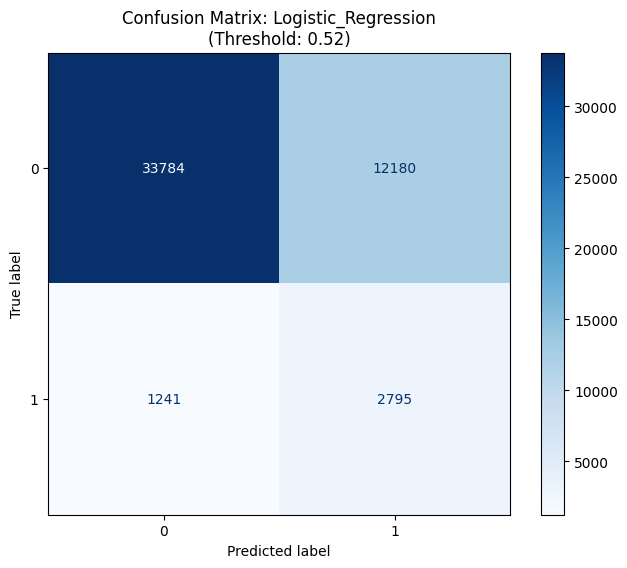

✅ Modèle Logistic_Regression optimisé.


2026/03/03 15:42:01 INFO mlflow.sklearn.utils: Logging the 5 best runs, 13 runs will be omitted.


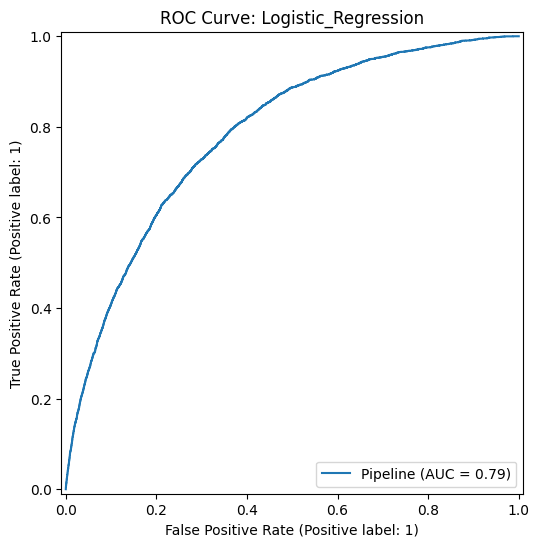

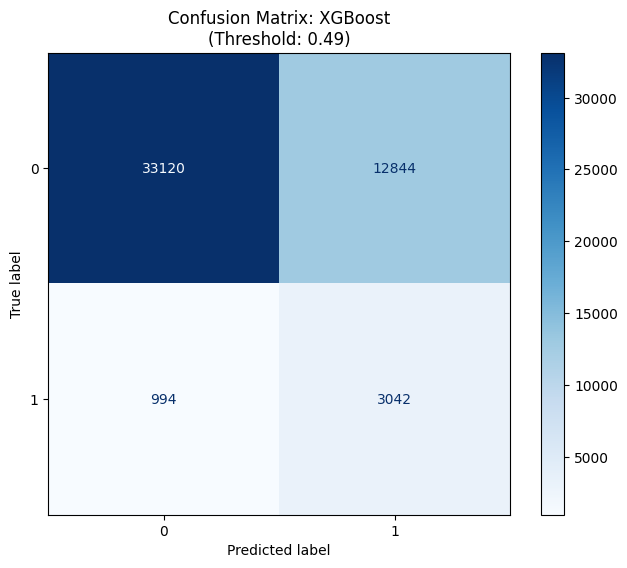

✅ Modèle XGBoost optimisé.
[LightGBM] [Info] Number of positive: 4036, number of negative: 45964
[LightGBM] [Info] Total Bins 35277
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 423
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/03/03 15:43:31 INFO mlflow.sklearn.utils: Logging the 5 best runs, 7 runs will be omitted.


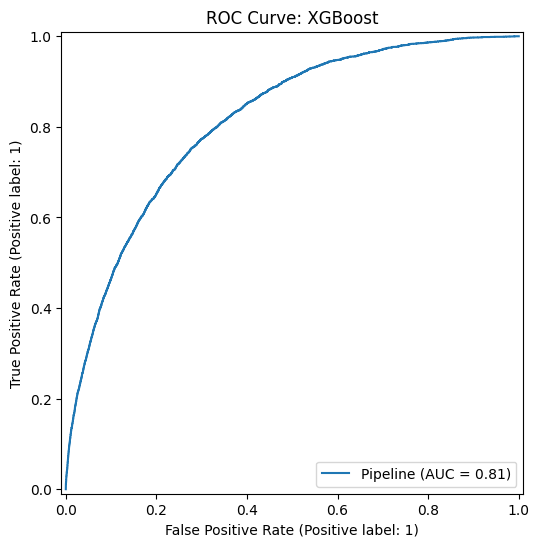

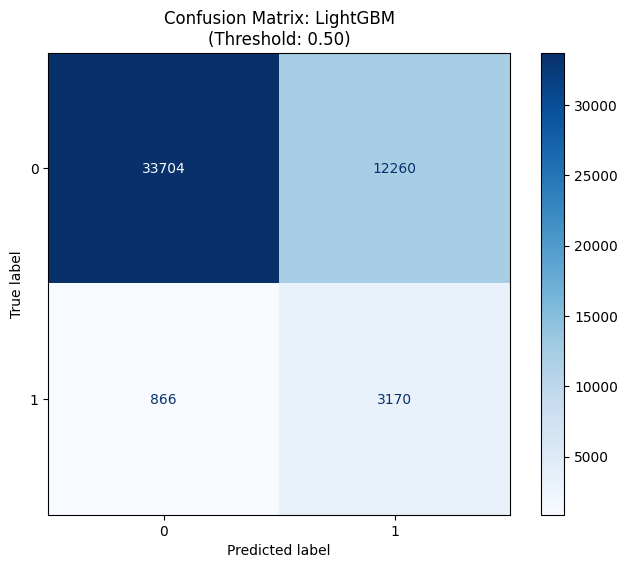

✅ Modèle LightGBM optimisé.


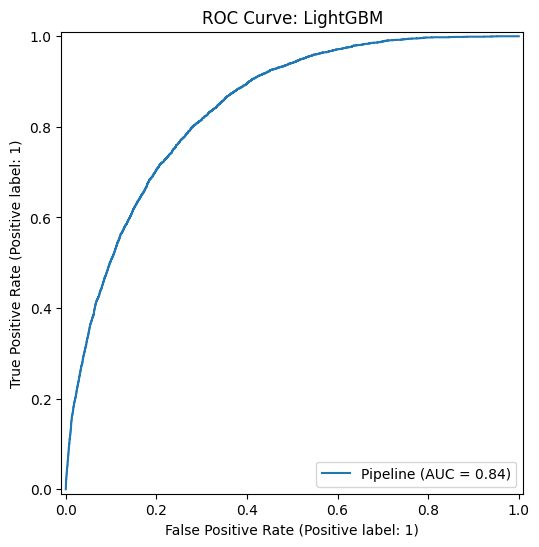

In [ ]:
for m_type in model_types:
    pipeline, param_grid = pipeline_model(m_type)
    
    with mlflow.start_run(run_name=f"Optimization_{m_type}"):
        mlflow.sklearn.autolog(log_models=True, log_datasets=True, log_input_examples=True, disable=False)
        
        # 1. Phase d'entraînement (GridSearch)
        grid = GridSearchCV(pipeline, param_grid, cv=cv_strategy, 
                            scoring=scoring_metrics, refit='Cost', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        # 2. Phase d'optimisation métier (Seuil)
        
        y_proba = grid.best_estimator_.predict_proba(X_train)[:, 1]
        best_thresh, min_cost, thresholds, costs = find_best_threshold(y_train, y_proba)
        y_pred_optimal = (y_proba >= best_thresh).astype(int)

        # Performances avec le seuil par défaut (0.5)
        y_pred_default = (y_proba >= 0.5).astype(int)
        cost_before = custom_business_cost(y_train, y_proba, threshold=0.5)
        acc_before = balanced_accuracy_score(y_train, y_pred_default)

        # Performances avec le seuil optimisé
        y_pred_optimal = (y_proba >= best_thresh).astype(int)
        acc_after = balanced_accuracy_score(y_train, y_pred_optimal)

        # Affichage du tableau comparatif
        performance_df = pd.DataFrame({
            "Métrique": ["Seuil de décision", "Coût Métier Total", "Balanced Accuracy"],
            "Avant (Défaut 0.5)": [0.5, f"{cost_before:.0f} €", f"{acc_before:.2%}"],
            "Après (Optimisé)": [f"{best_thresh:.2f}", f"{min_cost:.0f} €", f"{acc_after:.2%}"]
        })
        
        print(f"\n📊 COMPARATIF DE PERFORMANCE : {m_type}")
        display(performance_df)

        mlflow.log_metric("optimized_threshold", best_thresh)
        mlflow.log_metric("min_business_cost", min_cost)
        mlflow.log_metric("final_balanced_accuracy", balanced_accuracy_score(y_train, y_pred_optimal))

       # --- GRAPHIQUE 1 : COÛT VS SEUIL (Nouveau) ---
        fig_cost, ax_cost = plt.subplots(figsize=(10, 6))
        ax_cost.plot(thresholds, costs, color='red', label='Coût métier')
        ax_cost.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')
        ax_cost.axvline(best_thresh, color='black', linestyle='--', label=f'Best Thresh: {best_thresh:.2f}')
        ax_cost.set_title(f"Optimisation du Seuil - {m_type}\nMin Cost: {min_cost}")
        ax_cost.set_xlabel("Seuil de probabilité")
        ax_cost.set_ylabel("Coût total (FN*10 + FP*1)")
        ax_cost.legend()
        
        # Sauvegarde locale et dans MLflow
        cost_path = os.path.join(report_dir, f"cost_threshold_{m_type}.png")
        plt.savefig(cost_path)
        mlflow.log_artifact(cost_path)
        plt.show()

        # --- GRAPHIQUE 2 : MATRICE DE CONFUSION ---
        fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
        ConfusionMatrixDisplay.from_predictions(y_train, y_pred_optimal, cmap='Blues', ax=ax_cm)
        ax_cm.set_title(f"Confusion Matrix: {m_type}\n(Threshold: {best_thresh:.2f})")
        
        cm_path = os.path.join(report_dir, f"cm_{m_type}.png")
        plt.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        plt.show()

        # --- GRAPHIQUE 3 : COURBE ROC ---
        fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
        RocCurveDisplay.from_estimator(grid.best_estimator_, X_train, y_train, ax=ax_roc)
        ax_roc.set_title(f"ROC Curve: {m_type}")
        
        roc_path = os.path.join(report_dir, f"roc_{m_type}.png")
        plt.savefig(roc_path)
        mlflow.log_artifact(roc_path)
        plt.show()

### Registry

In [13]:
# On récupère les résultats de l'expérience pour choisir les champions
current_experiment = mlflow.get_experiment_by_name("Credit_Scoring_Training_Full")
runs = mlflow.search_runs(experiment_ids=[current_experiment.experiment_id])

for m_type in model_types:
    # On trouve le meilleur run pour ce modèle précis
    best_run = runs[runs['tags.mlflow.runName'] == f"Optimization_{m_type}"].iloc[0]
    run_id = best_run['run_id']
    
    # Enregistrement officiel
    model_uri = f"runs:/{run_id}/model"
    mlflow.register_model(model_uri, f"Champion_{m_type}")
    
    print(f"🏆 {m_type} enregistré dans le Model Registry.")

Successfully registered model 'Champion_Logistic_Regression'.
2026/03/03 15:43:33 WARNING mlflow.tracking._model_registry.fluent: Run with id cb6de3f27c7e4e8da0854ce31e8a7262 has no artifacts at artifact path 'model', registering model based on models:/m-53633dd87beb44b2b8b18433c5c494a8 instead
Created version '1' of model 'Champion_Logistic_Regression'.
Successfully registered model 'Champion_XGBoost'.
2026/03/03 15:43:33 WARNING mlflow.tracking._model_registry.fluent: Run with id 283379a170de407f95fccf016cc68e02 has no artifacts at artifact path 'model', registering model based on models:/m-ca848db7337d45ef9679ca2b4453b073 instead
Created version '1' of model 'Champion_XGBoost'.
Successfully registered model 'Champion_LightGBM'.


🏆 Logistic_Regression enregistré dans le Model Registry.
🏆 XGBoost enregistré dans le Model Registry.


2026/03/03 15:43:34 WARNING mlflow.tracking._model_registry.fluent: Run with id 5c1cbbf9bfb54ec091776d4581733a7f has no artifacts at artifact path 'model', registering model based on models:/m-f723aaff901a41199f3f32b0b86944bb instead


🏆 LightGBM enregistré dans le Model Registry.


Created version '1' of model 'Champion_LightGBM'.
